In [15]:
# purpose: build and evaluate first ML models
#dataset: Titanic (classification)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"All imports successful")

All imports successful


In [16]:
#load preprocessed data direclty

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# verify everything loaded correctly
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

#sanity check
print(f"\ny_train values: {y_train.value_counts().to_dict()}")

X_train: (712, 7)
X_test: (179, 7)
y_train: (712,)
y_test: (179,)

y_train values: {0: 439, 1: 273}


In [17]:
#import ML model
from sklearn.linear_model import LogisticRegression

#initialize model
#max_iter=1000 : maximum training iterations

lr_model = LogisticRegression(max_iter=1000, random_state=42) #here random_state controls the initial guess of parameters

print("Logistic Regression model created")
print(f"Model : {lr_model}")

Logistic Regression model created
Model : LogisticRegression(max_iter=1000, random_state=42)


In [18]:
#Training the model
lr_model.fit(X_train,y_train)

print("Model trained successfully")
print(f"Classes: {lr_model.classes_}")
print(f"Coefficients shape: {lr_model.coef_.shape}")

Model trained successfully
Classes: [0 1]
Coefficients shape: (1, 7)


Feature weights (what model learned) :
sex            2.547731
fare           0.438681
embarked_Q     0.313950
age           -0.038527
family_size   -0.261141
embarked_S    -0.296622
pclass        -0.847831
dtype: float64


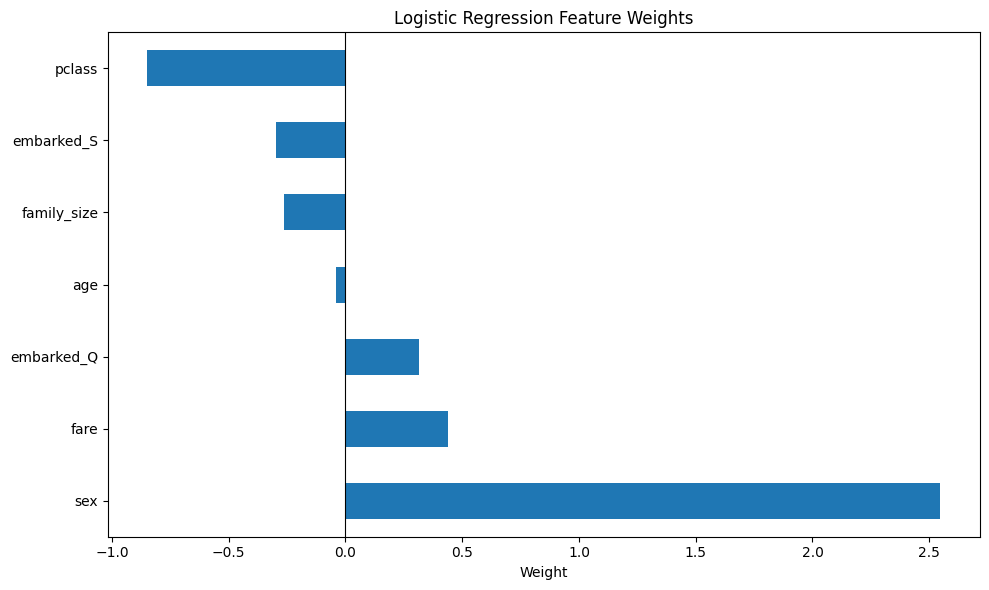

In [19]:
# what did model learn about each feature
coefficients =pd.Series(
    lr_model.coef_[0],
    index=X_train.columns
).sort_values(ascending=False)

print("Feature weights (what model learned) :")
print(coefficients)

#visualize
plt.figure(figsize=(10,6))
coefficients.plot(kind='barh')
plt.title('Logistic Regression Feature Weights')
plt.xlabel('Weight')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/01_feature_weights.png')
plt.show()

In [20]:
#make predictions on test set
y_pred = lr_model.predict(X_test)

#also get probabilities
y_pred_proba = lr_model.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"\nFirst 3 probabilities:")
print(f"[died_prob, survived_prob]")

for i in range(3):
    print(f"Passenger {i}: {y_pred_proba[i]}")

Predictions shape: (179,)
First 10 predictions: [0 0 0 0 1 1 1 0 0 0]

First 3 probabilities:
[died_prob, survived_prob]
Passenger 0: [0.89996415 0.10003585]
Passenger 1: [0.94662014 0.05337986]
Passenger 2: [0.85707092 0.14292908]


In [21]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

#accuracy = correct predictions/total predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.8101 (81.01%)


Accuracy : 81.01%

Classification Report
              precision    recall  f1-score   support

        Died       0.83      0.86      0.85       110
    Survived       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


Confusion Matrix:
[[95 15]
 [19 50]]


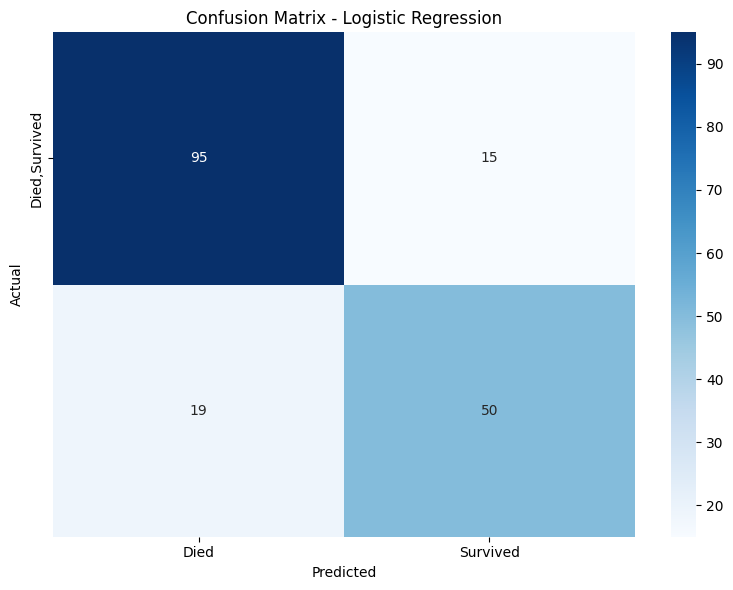

In [22]:
#full eavluation
print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"\nClassification Report")
print(classification_report(y_test,y_pred, target_names=['Died','Survived']))

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test,y_pred)
print(cm)

#visualize confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Died','Survived'],
    yticklabels=['Died,Survived']
)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/02_confusion_matrix.png')
plt.show()